# Importar bibliotecas y cargar Test

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

ROOT = Path.cwd().parent

test = pd.read_csv(
    ROOT / "data" / "split" / "telco_test.csv"
)

# Repetir la limpieza determinista.
for column in test.select_dtypes(
    include=["object", "string"]
).columns:
    test[column] = test[column].astype("string").str.strip()

test["TotalCharges"] = pd.to_numeric(
    test["TotalCharges"],
    errors="coerce"
)
test["TotalCharges"] = test["TotalCharges"].fillna(0)

y_test = test["Churn"].map({"No": 0, "Yes": 1})

X_test = test.drop(
    columns=["Churn", "customerID"]
)

print("Filas de Test:", len(test))
print("Variables predictoras:", X_test.shape[1])
print("Tasa de abandono en Test:", f"{y_test.mean():.2%}")

Filas de Test: 1409
Variables predictoras: 19
Tasa de abandono en Test: 26.54%


# Cargar los modelos y calcular las métricas

In [2]:
modelo_lr = joblib.load(
    ROOT / "models" / "logistic_regression_optuna.joblib"
)

modelo_rf = joblib.load(
    ROOT / "models" / "random_forest_optuna.joblib"
)

modelos = {
    "Regresión Logística": modelo_lr,
    "Random Forest": modelo_rf
}

resultados = []
predicciones = {}

for nombre, modelo in modelos.items():

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    predicciones[nombre] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tabla_resultados = pd.DataFrame(resultados)

display(
    tabla_resultados.round(4).sort_values(
        "F1-score", ascending=False
    )
)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.7651,0.5394,0.7861,0.6398,0.8432
0,Regresión Logística,0.7395,0.5060,0.7834,0.6149,0.8412


La diferencia más relevante para este proyecto es que Random Forest obtiene un mejor F1-score y detecta el 78,61% de los clientes que realmente abandonan, según el umbral de clasificación utilizado. La Regresión Logística tiene un ROC-AUC apenas superior, pero eso no compensa necesariamente las ventajas de Random Forest en las demás métricas.

Hay que recordar que estos resultados corresponden al conjunto Test, separado antes del análisis y de la optimización.

# Matrices de confusión

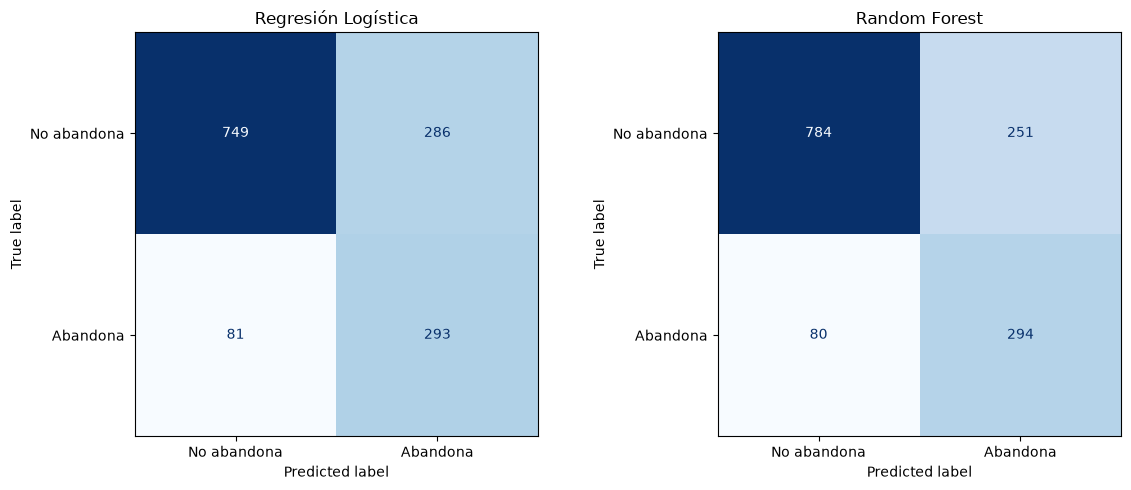

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nombre, datos) in zip(axes, predicciones.items()):

    cm = confusion_matrix(
        y_test,
        datos["y_pred"],
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No abandona", "Abandona"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

La Regresión Logística identifica correctamente a 293 clientes que abandonan, mientras que no detecta a 81 clientes que efectivamente se van. Además, clasifica erróneamente a 286 clientes que permanecen como posibles desertores.

Por su parte, Random Forest identifica correctamente a 294 clientes que abandonan y no detecta a 80. También reduce los falsos positivos a 251, frente a los 286 de la Regresión Logística.

En términos de negocio, Random Forest presenta un mejor comportamiento en esta comparación, ya que detecta prácticamente la misma cantidad de clientes que abandonan, pero genera menos alertas incorrectas. Esto puede ayudar a utilizar de forma más eficiente los recursos destinados a campañas de retención.

# Curvas ROC

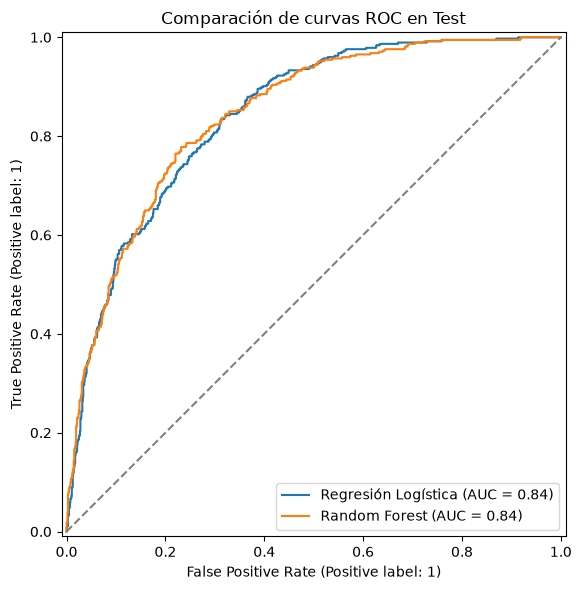

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, modelo in modelos.items():
    RocCurveDisplay.from_estimator(
        modelo,
        X_test,
        y_test,
        name=nombre,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Comparación de curvas ROC en Test")
plt.tight_layout()
plt.show()

En los resultados obtenidos, la Regresión Logística alcanza un ROC-AUC de 0,8432, mientras que Random Forest obtiene 0,8412. Ambos valores reflejan una buena capacidad de discriminación entre las dos clases y se encuentran considerablemente por encima de la diagonal de referencia, que representa un clasificador sin capacidad de discriminación.

Aunque la Regresión Logística obtiene un ROC-AUC ligeramente superior, la diferencia es pequeña. Por lo tanto, este resultado no significa por sí solo que sea el mejor modelo para el negocio. La selección también debe considerar métricas como Recall, Precision y F1-score, además de los errores observados en las matrices de confusión.

En este caso, Random Forest presenta una ventaja en las predicciones realizadas con el umbral actual, pues obtiene un mayor Recall y F1-score, además de reducir los falsos positivos. Por ello, resulta una alternativa prometedora para apoyar la identificación de clientes en riesgo de abandono.

# Guardar los resultados

In [5]:
output_path = ROOT / "reports" / "supervised_test_results.csv"

output_path.parent.mkdir(parents=True, exist_ok=True)

tabla_resultados.to_csv(output_path, index=False)

print("Resultados guardados en:", output_path)

Resultados guardados en: c:\Users\fusk5\Desktop\telco-churn-ml\reports\supervised_test_results.csv
